# ============================================================
# INDIA ELECTRIC VEHICLE MARKET ANALYSIS
# Python Data Analyst Portfolio Project
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


# ============================================================
# 2. PROJECT CONFIGURATION
# ============================================================


In [9]:
FILE_PATH = r"C:\Users\Nimesh\Desktop\Python\India EV Dataset\India_EV_Dataset.csv"

OUTPUT_DIR = "EV_Analysis_Output"
CHART_DIR = os.path.join(OUTPUT_DIR, "Charts")
TABLE_DIR = os.path.join(OUTPUT_DIR, "Tables")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)


# ============================================================
# 3. LOAD DATA
# ============================================================


In [11]:
df = pd.read_csv(FILE_PATH)

print("=" * 70)
print("INDIA ELECTRIC VEHICLE MARKET ANALYSIS")
print("=" * 70)

print("\nDataset loaded successfully!")

print("\nShape of dataset:")
print(df.shape)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


INDIA ELECTRIC VEHICLE MARKET ANALYSIS

Dataset loaded successfully!

Shape of dataset:
(25533, 14)

Number of rows: 25533
Number of columns: 14


# ============================================================
# 4. DATASET OVERVIEW
# ============================================================


In [12]:
print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nColumns:")
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nDataset information:")
print(df.info())



DATASET OVERVIEW

Columns:
1. County
2. City
3. State
4. Postal Code
5. Model Year
6. Make
7. Model
8. Electric Vehicle Type
9. Clean Alternative Fuel Vehicle (CAFV) Eligibility
10. Electric Range
11. Base MSRP
12. DOL Vehicle ID
13. Vehicle Location
14. Electric Utility

Data types:
County                                                 str
City                                                   str
State                                                  str
Postal Code                                          int64
Model Year                                           int64
Make                                                   str
Model                                                  str
Electric Vehicle Type                                  str
Clean Alternative Fuel Vehicle (CAFV) Eligibility      str
Electric Range                                       int64
Base MSRP                                            int64
DOL Vehicle ID                                       int64
Vehicl


# ============================================================
# 5. DATA PROFILING
# ============================================================


In [13]:
print("\n" + "=" * 70)
print("DATA PROFILING")
print("=" * 70)

profile = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str),
    "Missing_Values": df.isnull().sum().values,
    "Missing_%": (df.isnull().mean() * 100).round(2).values,
    "Unique_Values": df.nunique().values
})

print(profile.to_string(index=False))

profile.to_csv(
    os.path.join(TABLE_DIR, "01_data_profile.csv"),
    index=False
)



DATA PROFILING
                                           Column Data_Type  Missing_Values  Missing_%  Unique_Values
                                           County       str               0        0.0              1
                                             City       str               0        0.0             35
                                            State       str               0        0.0             15
                                      Postal Code     int64               0        0.0          25141
                                       Model Year     int64               0        0.0              7
                                             Make       str               0        0.0              8
                                            Model       str               0        0.0              8
                            Electric Vehicle Type       str               0        0.0              2
Clean Alternative Fuel Vehicle (CAFV) Eligibility       str       

# ============================================================
# 6. DUPLICATE CHECK
# ============================================================


In [14]:
print("\n" + "=" * 70)
print("DUPLICATE ANALYSIS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate records:")
    print(df[df.duplicated()].head())
else:
    print("No duplicate rows found.")

# Duplicate vehicle IDs
duplicate_vehicle_ids = df["DOL Vehicle ID"].duplicated().sum()

print("\nDuplicate DOL Vehicle IDs:", duplicate_vehicle_ids)



DUPLICATE ANALYSIS
Duplicate rows: 0
No duplicate rows found.

Duplicate DOL Vehicle IDs: 0


# ============================================================
# 7. DATA QUALITY CHECKS
# ============================================================


In [16]:
print("\n" + "=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)

print("\nModel Year range:")
print(df["Model Year"].min(), "to", df["Model Year"].max())

print("\nElectric Range :")
print(df["Electric Range"].min(), "to", df["Electric Range"].max())

print("\nBase MSRP range:")
print(df["Base MSRP"].min(), "to", df["Base MSRP"].max())

# Invalid values
invalid_range = (df["Electric Range"] <= 0).sum()
invalid_price = (df["Base MSRP"] <= 0).sum()
invalid_year = (df["Model Year"] < 2000).sum()

print("\nInvalid Electric Range values:", invalid_range)
print("Invalid Base MSRP values:", invalid_price)
print("Invalid Model Year values:", invalid_year)



DATA QUALITY CHECKS

Model Year range:
2018 to 2024

Electric Range :
80 to 519

Base MSRP range:
900422 to 4499944

Invalid Electric Range values: 0
Invalid Base MSRP values: 0
Invalid Model Year values: 0


# ============================================================
# 8. BASIC STATISTICS
# ============================================================


In [18]:
print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

numeric_summary = df.describe().round(2)

print(numeric_summary)

numeric_summary.to_csv(
    os.path.join(TABLE_DIR, "02_numeric_summary.csv")
)



DESCRIPTIVE STATISTICS
       Postal Code  Model Year  Electric Range   Base MSRP  DOL Vehicle ID
count     25533.00    25533.00        25533.00    25533.00        25533.00
mean     547649.36     2021.00          298.30  2704518.99       112767.00
std      261038.42        2.01          126.88  1037085.09         7370.89
min      100057.00     2018.00           80.00   900422.00       100001.00
25%      319175.00     2019.00          187.00  1816731.00       106384.00
50%      549423.00     2021.00          298.00  2716403.00       112767.00
75%      773298.00     2023.00          408.00  3599703.00       119150.00
max      999885.00     2024.00          519.00  4499944.00       125533.00


# ============================================================
# 9. CATEGORICAL ANALYSIS
# ============================================================


In [19]:
categorical_columns = [
    "State",
    "City",
    "Make",
    "Model",
    "Electric Vehicle Type",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    "Electric Utility"
]

for column in categorical_columns:

    print("\n" + "-" * 60)
    print(column)

    print(df[column].value_counts().head(15))



------------------------------------------------------------
State
State
Tamil Nadu        2287
Maharashtra       2262
Rajasthan         2195
Uttar Pradesh     2187
Gujarat           2177
Karnataka         2172
Telangana         1495
Odisha            1474
Bihar             1463
West Bengal       1456
Andhra Pradesh    1443
Haryana           1431
Punjab            1402
Kerala            1389
Delhi              700
Name: count, dtype: int64

------------------------------------------------------------
City
City
Chennai          795
Cuttack          788
Kanpur           785
Coimbatore       784
Udaipur          783
Mumbai           776
Kolkata          763
Hyderabad        761
Patna            761
Nagpur           757
Visakhapatnam    757
Faridabad        749
Mangaluru        742
Ahmedabad        740
Jodhpur          737
Name: count, dtype: int64

------------------------------------------------------------
Make
Make
Tata Motors          3250
BYD India            3246
TVS Motor         

# ============================================================
# 10. KPI CALCULATIONS
# ============================================================


In [20]:
total_vehicles = len(df)
total_manufacturers = df["Make"].nunique()
total_models = df["Model"].nunique()
total_states = df["State"].nunique()
total_cities = df["City"].nunique()

average_range = df["Electric Range"].mean()
median_range = df["Electric Range"].median()

average_price = df["Base MSRP"].mean()
median_price = df["Base MSRP"].median()

bev_count = (
    df["Electric Vehicle Type"]
    .eq("Battery Electric Vehicle (BEV)")
    .sum()
)

phev_count = (
    df["Electric Vehicle Type"]
    .eq("Plug-in Hybrid Electric Vehicle (PHEV)")
    .sum()
)

eligible_count = (
    df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"]
    .eq("Eligible")
    .sum()
)

kpis = pd.DataFrame({
    "Metric": [
        "Total EV Records",
        "Manufacturers",
        "Models",
        "States",
        "Cities",
        "Average Electric Range",
        "Median Electric Range",
        "Average Base MSRP",
        "Median Base MSRP",
        "BEV Vehicles",
        "PHEV Vehicles",
        "CAFV Eligible Vehicles"
    ],

    "Value": [
        total_vehicles,
        total_manufacturers,
        total_models,
        total_states,
        total_cities,
        round(average_range, 2),
        median_range,
        round(average_price, 2),
        median_price,
        bev_count,
        phev_count,
        eligible_count
    ]
})

print("\n" + "=" * 70)
print("KEY PERFORMANCE INDICATORS")
print("=" * 70)

print(kpis.to_string(index=False))

kpis.to_csv(
    os.path.join(TABLE_DIR, "03_key_metrics.csv"),
    index=False
)



KEY PERFORMANCE INDICATORS
                Metric      Value
      Total EV Records   25533.00
         Manufacturers       8.00
                Models       8.00
                States      15.00
                Cities      35.00
Average Electric Range     298.30
 Median Electric Range     298.00
     Average Base MSRP 2704518.99
      Median Base MSRP 2716403.00
          BEV Vehicles   21684.00
         PHEV Vehicles    3849.00
CAFV Eligible Vehicles   20346.00



# ============================================================
# 11. MODEL YEAR ANALYSIS
# ============================================================


In [21]:
year_analysis = (
    df.groupby("Model Year")
    .agg(
        EV_Count=("DOL Vehicle ID", "count"),
        Average_Range=("Electric Range", "mean"),
        Average_Price=("Base MSRP", "mean")
    )
    .reset_index()
)

year_analysis["YoY_Growth_%"] = (
    year_analysis["EV_Count"]
    .pct_change() * 100
).round(2)

print("\n" + "=" * 70)
print("EV ANALYSIS BY MODEL YEAR")
print("=" * 70)

print(year_analysis.round(2).to_string(index=False))

year_analysis.to_csv(
    os.path.join(TABLE_DIR, "04_year_analysis.csv"),
    index=False
)



EV ANALYSIS BY MODEL YEAR
 Model Year  EV_Count  Average_Range  Average_Price  YoY_Growth_%
       2018      3704         298.17     2697344.69           NaN
       2019      3662         301.02     2707759.10         -1.13
       2020      3478         295.18     2688916.01         -5.02
       2021      3666         297.84     2708551.00          5.41
       2022      3648         298.17     2701658.17         -0.49
       2023      3756         297.69     2713221.93          2.96
       2024      3619         299.93     2713345.25         -3.65


# ============================================================
# 12. YEARLY EV COUNT CHART
# ============================================================


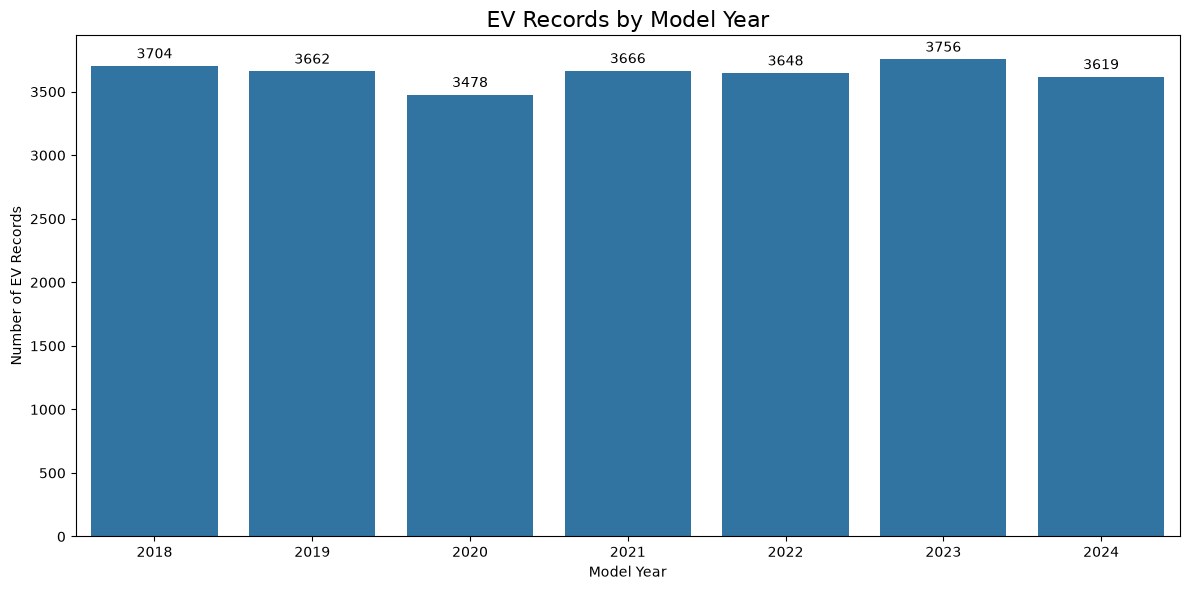

In [22]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=year_analysis,
    x="Model Year",
    y="EV_Count"
)

plt.title("EV Records by Model Year", fontsize=16)
plt.xlabel("Model Year")
plt.ylabel("Number of EV Records")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "01_ev_by_model_year.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# ============================================================
# 13. EV GROWTH TREND
# ============================================================


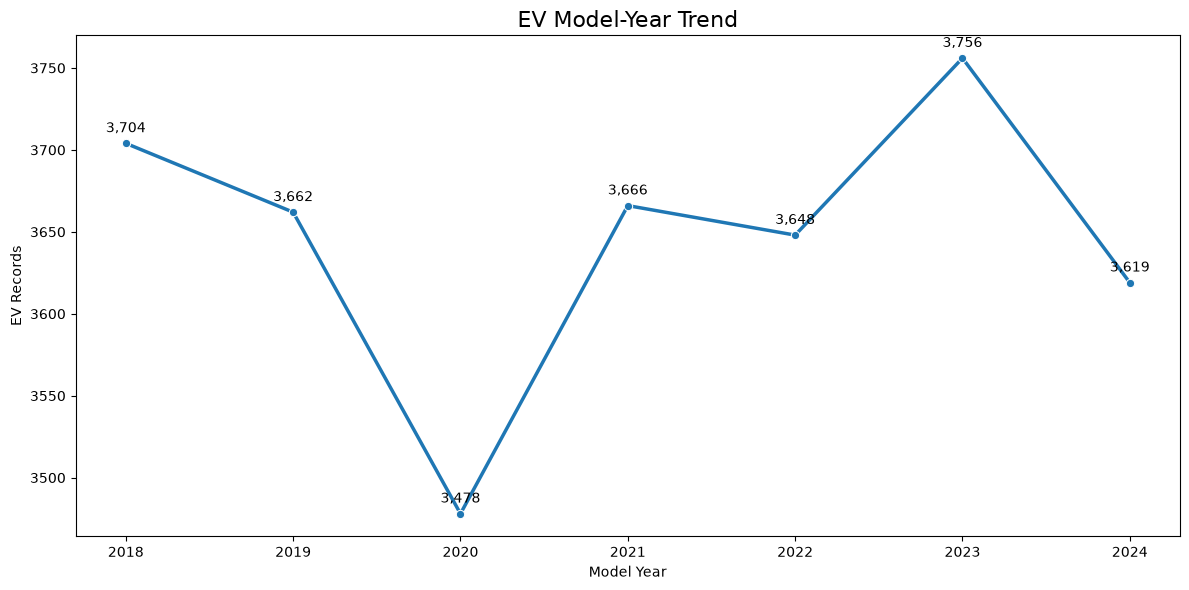

In [23]:
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=year_analysis,
    x="Model Year",
    y="EV_Count",
    marker="o",
    linewidth=2.5
)

plt.title("EV Model-Year Trend", fontsize=16)
plt.xlabel("Model Year")
plt.ylabel("EV Records")

for x, y in zip(
    year_analysis["Model Year"],
    year_analysis["EV_Count"]
):
    ax.annotate(
        f"{y:,}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "02_ev_growth_trend.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. STATE ANALYSIS
# ============================================================


In [24]:
state_analysis = (
    df.groupby("State")
    .agg(
        EV_Count=("DOL Vehicle ID", "count"),
        Average_Range=("Electric Range", "mean"),
        Average_Price=("Base MSRP", "mean")
    )
    .sort_values("EV_Count", ascending=False)
    .reset_index()
)

state_analysis["Market_Share_%"] = (
    state_analysis["EV_Count"]
    / total_vehicles * 100
).round(2)

print("\n" + "=" * 70)
print("STATE ANALYSIS")
print("=" * 70)

print(state_analysis.round(2).to_string(index=False))

state_analysis.to_csv(
    os.path.join(TABLE_DIR, "05_state_analysis.csv"),
    index=False
)



STATE ANALYSIS
         State  EV_Count  Average_Range  Average_Price  Market_Share_%
    Tamil Nadu      2287         294.03     2705079.75            8.96
   Maharashtra      2262         296.45     2718148.42            8.86
     Rajasthan      2195         298.35     2704548.09            8.60
 Uttar Pradesh      2187         300.27     2722003.85            8.57
       Gujarat      2177         296.40     2709415.05            8.53
     Karnataka      2172         306.84     2703077.14            8.51
     Telangana      1495         297.68     2658106.63            5.86
        Odisha      1474         296.20     2714841.68            5.77
         Bihar      1463         292.81     2727678.43            5.73
   West Bengal      1456         295.75     2744588.62            5.70
Andhra Pradesh      1443         296.71     2712567.65            5.65
       Haryana      1431         292.86     2692861.44            5.60
        Punjab      1402         303.37     2694345.12       

# ============================================================
# 15. TOP 10 STATES
# ============================================================


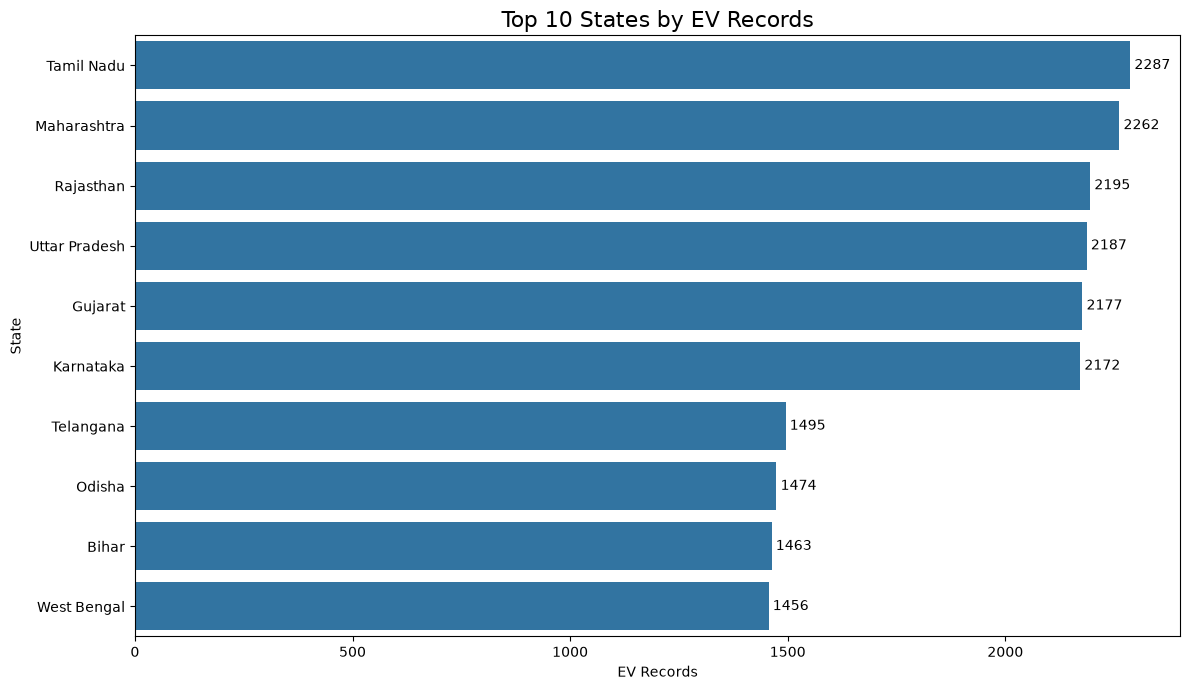

In [26]:
top_states = state_analysis.head(10)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_states,
    y="State",
    x="EV_Count"
)

plt.title("Top 10 States by EV Records", fontsize=16)
plt.xlabel("EV Records")
plt.ylabel("State")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "03_top_10_states.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. CITY ANALYSIS
# ============================================================


In [27]:
city_analysis = (
    df.groupby(["State", "City"])
    .agg(
        EV_Count=("DOL Vehicle ID", "count"),
        Average_Range=("Electric Range", "mean"),
        Average_Price=("Base MSRP", "mean")
    )
    .sort_values("EV_Count", ascending=False)
    .reset_index()
)

print("\n" + "=" * 70)
print("TOP 15 CITIES BY EV RECORDS")
print("=" * 70)

print(city_analysis.head(15).round(2).to_string(index=False))

city_analysis.to_csv(
    os.path.join(TABLE_DIR, "06_city_analysis.csv"),
    index=False
)



TOP 15 CITIES BY EV RECORDS
         State          City  EV_Count  Average_Range  Average_Price
    Tamil Nadu       Chennai       795         293.49     2682623.70
        Odisha       Cuttack       788         288.41     2676640.99
 Uttar Pradesh        Kanpur       785         313.69     2747278.74
    Tamil Nadu    Coimbatore       784         300.49     2680660.14
     Rajasthan       Udaipur       783         298.05     2705515.37
   Maharashtra        Mumbai       776         292.64     2709674.78
   West Bengal       Kolkata       763         296.28     2772130.05
     Telangana     Hyderabad       761         295.01     2678448.97
         Bihar         Patna       761         293.14     2717390.94
Andhra Pradesh Visakhapatnam       757         299.53     2716039.65
   Maharashtra        Nagpur       757         298.70     2763634.21
       Haryana     Faridabad       749         295.06     2704917.88
     Karnataka     Mangaluru       742         303.42     2695658.13
     

# ============================================================
# 17. MANUFACTURER ANALYSIS
# ============================================================


In [28]:
manufacturer_analysis = (
    df.groupby("Make")
    .agg(
        EV_Count=("DOL Vehicle ID", "count"),
        Average_Range=("Electric Range", "mean"),
        Average_Price=("Base MSRP", "mean"),
        Maximum_Range=("Electric Range", "max"),
        Minimum_Range=("Electric Range", "min")
    )
    .sort_values("EV_Count", ascending=False)
    .reset_index()
)

manufacturer_analysis["Market_Share_%"] = (
    manufacturer_analysis["EV_Count"]
    / total_vehicles * 100
).round(2)

print("\n" + "=" * 70)
print("MANUFACTURER ANALYSIS")
print("=" * 70)

print(
    manufacturer_analysis.round(2)
    .to_string(index=False)
)

manufacturer_analysis.to_csv(
    os.path.join(TABLE_DIR, "07_manufacturer_analysis.csv"),
    index=False
)



MANUFACTURER ANALYSIS
             Make  EV_Count  Average_Range  Average_Price  Maximum_Range  Minimum_Range  Market_Share_%
      Tata Motors      3250         298.34     2694154.76            519             80           12.73
        BYD India      3246         298.19     2690243.39            519             80           12.71
        TVS Motor      3236         297.78     2713438.11            519             80           12.67
Mahindra Electric      3209         298.83     2705382.12            519             80           12.57
     Ather Energy      3197         300.62     2725111.15            519             80           12.52
   MG Motor India      3155         297.63     2700683.51            519             80           12.36
     Ola Electric      3140         298.96     2703514.47            519             80           12.30
       Hyundai EV      3100         296.01     2703813.31            519             80           12.14


# ============================================================
# 18. TOP MANUFACTURERS
# ============================================================


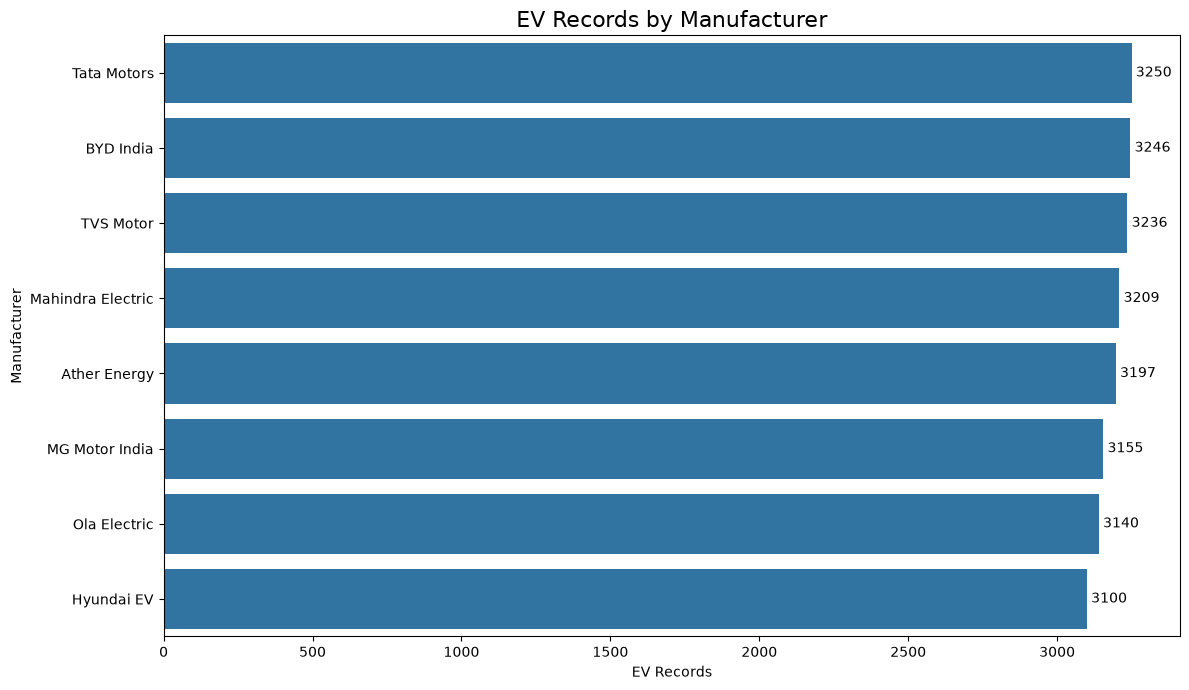

In [29]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=manufacturer_analysis,
    y="Make",
    x="EV_Count"
)

plt.title("EV Records by Manufacturer", fontsize=16)
plt.xlabel("EV Records")
plt.ylabel("Manufacturer")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "04_manufacturer_market_presence.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. MODEL ANALYSIS
# ============================================================


In [30]:
model_analysis = (
    df.groupby(["Make", "Model"])
    .agg(
        EV_Count=("DOL Vehicle ID", "count"),
        Average_Range=("Electric Range", "mean"),
        Maximum_Range=("Electric Range", "max"),
        Average_Price=("Base MSRP", "mean")
    )
    .sort_values("EV_Count", ascending=False)
    .reset_index()
)

print("\n" + "=" * 70)
print("TOP 15 EV MODELS")
print("=" * 70)

print(model_analysis.head(15).round(2).to_string(index=False))

model_analysis.to_csv(
    os.path.join(TABLE_DIR, "08_model_analysis.csv"),
    index=False
)



TOP 15 EV MODELS
             Make    Model  EV_Count  Average_Range  Maximum_Range  Average_Price
      Tata Motors    ZS EV       436         306.61            519     2684433.64
     Ola Electric Nexon EV       433         306.45            519     2754337.51
        BYD India    iQube       431         295.53            517     2612796.05
        TVS Motor     450X       429         304.76            517     2707121.61
Mahindra Electric    ZS EV       427         307.29            519     2750551.61
   MG Motor India  Kona EV       423         297.03            517     2697163.93
      Tata Motors   XUV400       421         286.12            518     2655930.43
      Tata Motors    iQube       421         291.29            519     2641409.64
        BYD India     450X       419         287.92            518     2691303.32
        TVS Motor   Atto 3       416         291.23            518     2756463.71
        TVS Motor  Kona EV       415         304.58            517     2658574.8

# ============================================================
# 20. TOP 10 EV MODELS
# ============================================================


In [ ]:
top_models = model_analysis.head(10)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_models,
    y="Model",
    x="EV_Count"
)

plt.title("Top 10 EV Models by Number of Records", fontsize=16)
plt.xlabel("EV Records")
plt.ylabel("Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "05_top_10_models.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. EV TYPE ANALYSIS
# ============================================================


In [31]:
ev_type_analysis = (
    df["Electric Vehicle Type"]
    .value_counts()
    .reset_index()
)

ev_type_analysis.columns = [
    "EV_Type",
    "Vehicle_Count"
]

ev_type_analysis["Share_%"] = (
    ev_type_analysis["Vehicle_Count"]
    / total_vehicles * 100
).round(2)

print("\n" + "=" * 70)
print("BEV VS PHEV ANALYSIS")
print("=" * 70)

print(ev_type_analysis.to_string(index=False))

ev_type_analysis.to_csv(
    os.path.join(TABLE_DIR, "09_ev_type_analysis.csv"),
    index=False
)



BEV VS PHEV ANALYSIS
                               EV_Type  Vehicle_Count  Share_%
        Battery Electric Vehicle (BEV)          21684    84.93
Plug-in Hybrid Electric Vehicle (PHEV)           3849    15.07


# ============================================================
# 22. BEV VS PHEV CHART
# ============================================================


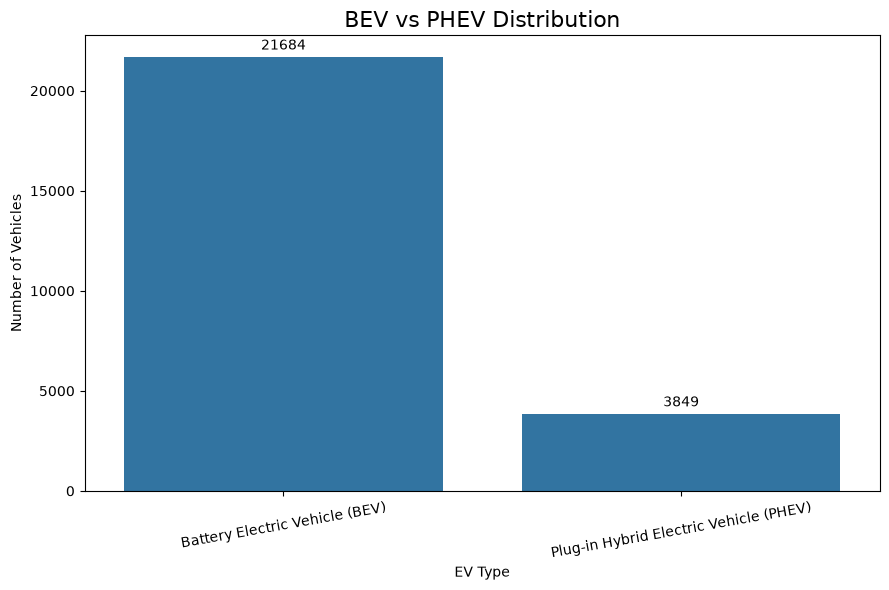

In [32]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=ev_type_analysis,
    x="EV_Type",
    y="Vehicle_Count"
)

plt.title("BEV vs PHEV Distribution", fontsize=16)
plt.xlabel("EV Type")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "06_bev_vs_phev.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 23. CAFV ELIGIBILITY ANALYSIS
# ============================================================


In [34]:
cafv_analysis = (
    df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"]
    .value_counts()
    .reset_index()
)

cafv_analysis.columns = [
    "CAFV_Status",
    "Vehicle_Count"
]

cafv_analysis["Share_%"] = (
    cafv_analysis["Vehicle_Count"]
    / total_vehicles * 100
).round(2)

print("\n" + "=" * 70)
print("CAFV ELIGIBILITY")
print("=" * 70)

print(cafv_analysis.to_string(index=False))

cafv_analysis.to_csv(
    os.path.join(TABLE_DIR, "10_cafv_analysis.csv"),
    index=False
)



CAFV ELIGIBILITY
 CAFV_Status  Vehicle_Count  Share_%
    Eligible          20346    79.69
Not Eligible           5187    20.31


# ============================================================
# 24. CAFV ELIGIBILITY CHART
# ============================================================


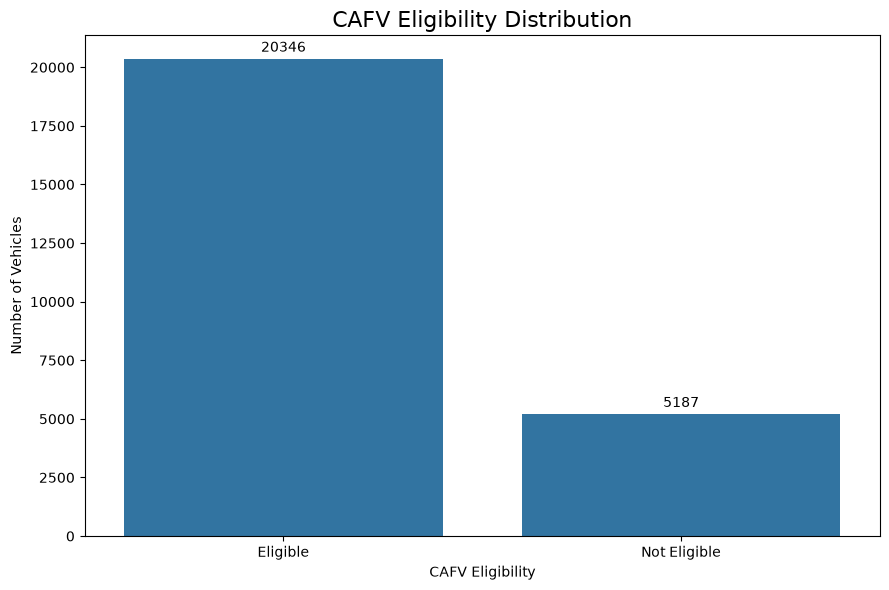

In [35]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=cafv_analysis,
    x="CAFV_Status",
    y="Vehicle_Count"
)

plt.title("CAFV Eligibility Distribution", fontsize=16)
plt.xlabel("CAFV Eligibility")
plt.ylabel("Number of Vehicles")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "07_cafv_eligibility.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 25. ELECTRIC RANGE ANALYSIS
# ============================================================


In [36]:
range_analysis = (
    df.groupby("Make")
    .agg(
        Average_Range=("Electric Range", "mean"),
        Maximum_Range=("Electric Range", "max")
    )
    .sort_values(
        "Average_Range",
        ascending=False
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("MANUFACTURERS BY ELECTRIC RANGE")
print("=" * 70)

print(range_analysis.round(2).to_string(index=False))

range_analysis.to_csv(
    os.path.join(TABLE_DIR, "11_range_analysis.csv"),
    index=False
)



MANUFACTURERS BY ELECTRIC RANGE
             Make  Average_Range  Maximum_Range
     Ather Energy         300.62            519
     Ola Electric         298.96            519
Mahindra Electric         298.83            519
      Tata Motors         298.34            519
        BYD India         298.19            519
        TVS Motor         297.78            519
   MG Motor India         297.63            519
       Hyundai EV         296.01            519


# ============================================================
# 26. RANGE DISTRIBUTION
# ============================================================


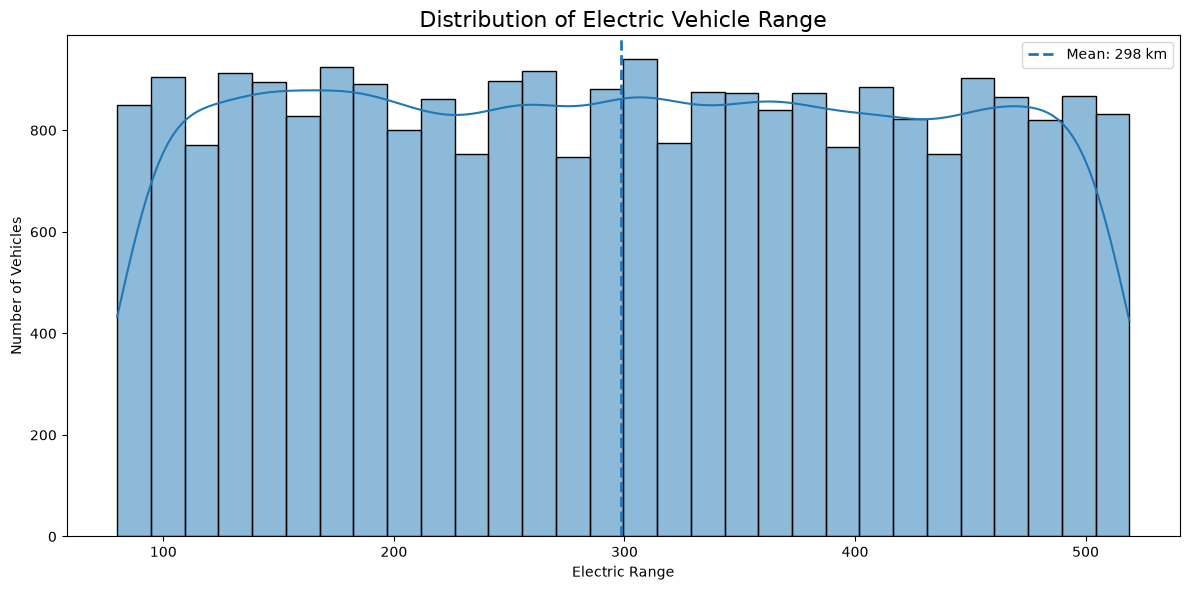

In [37]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Electric Range",
    bins=30,
    kde=True
)

plt.axvline(
    df["Electric Range"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df['Electric Range'].mean():.0f} km"
)

plt.title("Distribution of Electric Vehicle Range", fontsize=16)
plt.xlabel("Electric Range")
plt.ylabel("Number of Vehicles")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "08_range_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 27. TOP RANGE MODELS
# ============================================================


In [38]:
top_range_models = (
    df.groupby(["Make", "Model"])
    .agg(
        Average_Range=("Electric Range", "mean"),
        Maximum_Range=("Electric Range", "max"),
        Vehicle_Count=("DOL Vehicle ID", "count")
    )
    .sort_values(
        "Average_Range",
        ascending=False
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("TOP 10 MODELS BY AVERAGE ELECTRIC RANGE")
print("=" * 70)

print(
    top_range_models
    .head(10)
    .round(2)
    .to_string(index=False)
)

top_range_models.to_csv(
    os.path.join(TABLE_DIR, "12_top_range_models.csv"),
    index=False
)



TOP 10 MODELS BY AVERAGE ELECTRIC RANGE
             Make    Model  Average_Range  Maximum_Range  Vehicle_Count
     Ather Energy  Kona EV         311.43            518            412
     Ather Energy    ZS EV         307.59            519            406
Mahindra Electric    ZS EV         307.29            519            427
       Hyundai EV   Atto 3         307.08            519            381
   MG Motor India    iQube         306.94            518            402
        BYD India   Atto 3         306.87            519            411
      Tata Motors    ZS EV         306.61            519            436
     Ola Electric Nexon EV         306.45            519            433
Mahindra Electric Nexon EV         306.38            519            402
      Tata Motors Nexon EV         306.12            519            408


# ============================================================
# 28. PRICE ANALYSIS
# ============================================================

In [39]:
price_analysis = (
    df.groupby("Make")
    .agg(
        Average_Price=("Base MSRP", "mean"),
        Median_Price=("Base MSRP", "median"),
        Minimum_Price=("Base MSRP", "min"),
        Maximum_Price=("Base MSRP", "max")
    )
    .sort_values(
        "Average_Price",
        ascending=False
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("PRICE ANALYSIS BY MANUFACTURER")
print("=" * 70)

print(
    price_analysis
    .round(2)
    .to_string(index=False)
)

price_analysis.to_csv(
    os.path.join(TABLE_DIR, "13_price_analysis.csv"),
    index=False
)



PRICE ANALYSIS BY MANUFACTURER
             Make  Average_Price  Median_Price  Minimum_Price  Maximum_Price
     Ather Energy     2725111.15     2747602.0         903547        4499944
        TVS Motor     2713438.11     2729069.0         901825        4497448
Mahindra Electric     2705382.12     2709869.0         903196        4499721
       Hyundai EV     2703813.31     2741859.0         900422        4499618
     Ola Electric     2703514.47     2704183.5         902433        4499783
   MG Motor India     2700683.51     2685958.0         903285        4497492
      Tata Motors     2694154.76     2697000.0         904092        4499024
        BYD India     2690243.39     2697173.0         901585        4498793


# ============================================================
# 29. PRICE DISTRIBUTION
# ============================================================


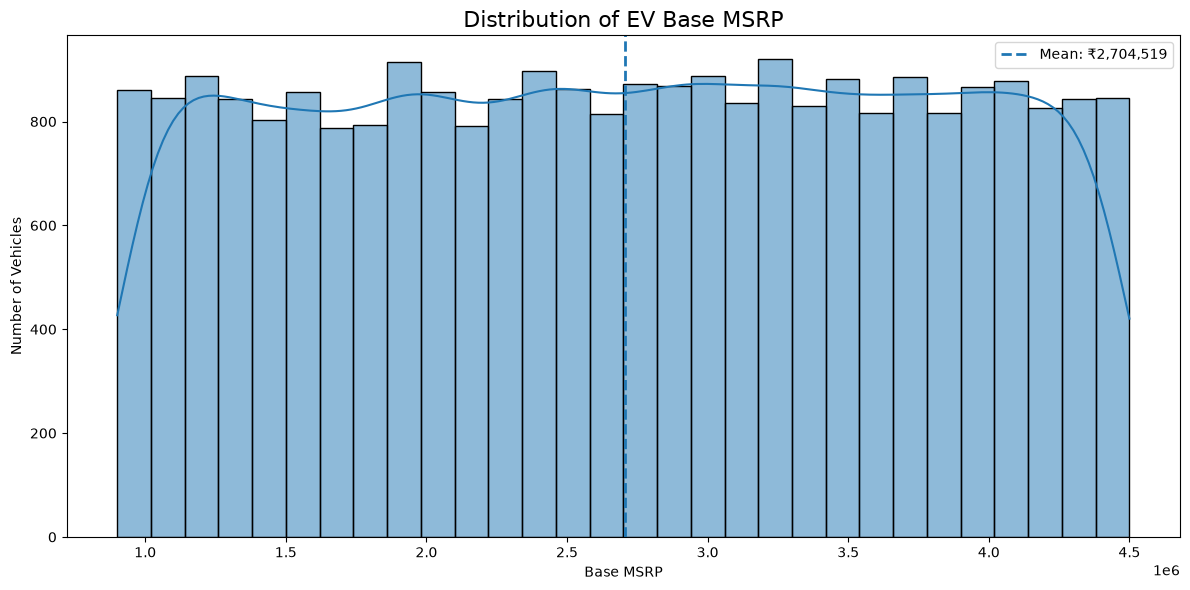

In [40]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Base MSRP",
    bins=30,
    kde=True
)

plt.axvline(
    df["Base MSRP"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean: ₹{df['Base MSRP'].mean():,.0f}"
)

plt.title("Distribution of EV Base MSRP", fontsize=16)
plt.xlabel("Base MSRP")
plt.ylabel("Number of Vehicles")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "09_price_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# ============================================================
# 30. RANGE VS PRICE
# ============================================================


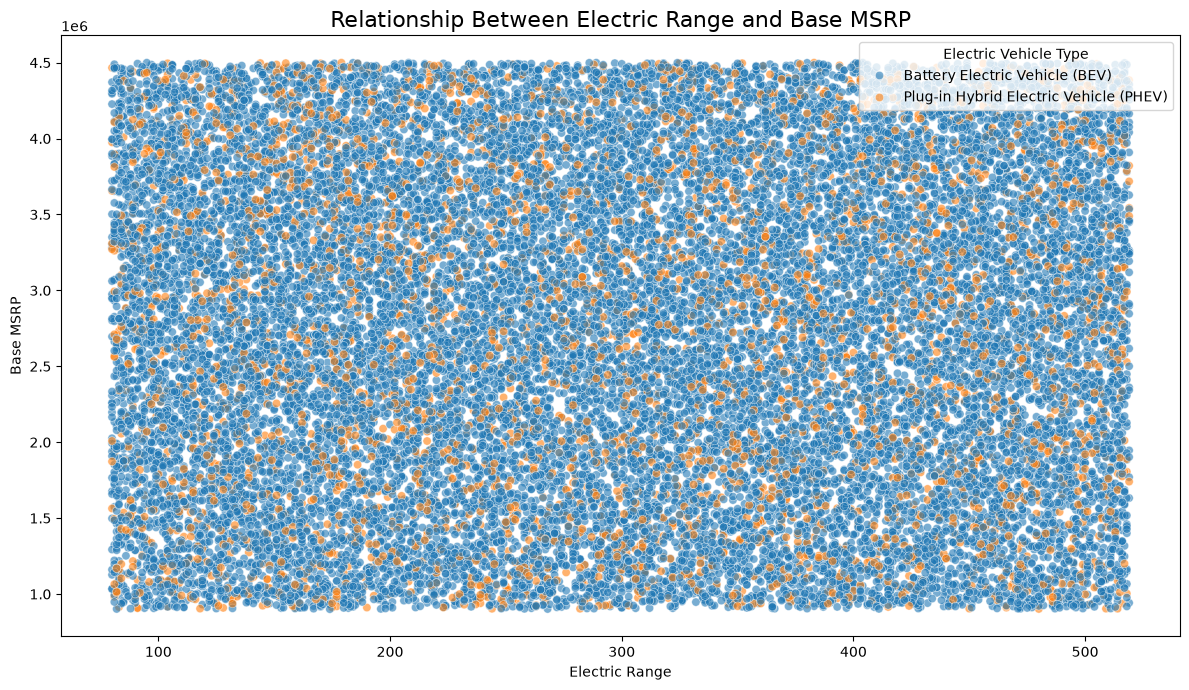

In [41]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Electric Range",
    y="Base MSRP",
    hue="Electric Vehicle Type",
    alpha=0.6
)

plt.title(
    "Relationship Between Electric Range and Base MSRP",
    fontsize=16
)

plt.xlabel("Electric Range")
plt.ylabel("Base MSRP")

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "10_range_vs_price.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 31. CORRELATION ANALYSIS
# ============================================================



CORRELATION MATRIX
                Model Year  Electric Range  Base MSRP
Model Year           1.000           0.001      0.005
Electric Range       0.001           1.000     -0.002
Base MSRP            0.005          -0.002      1.000


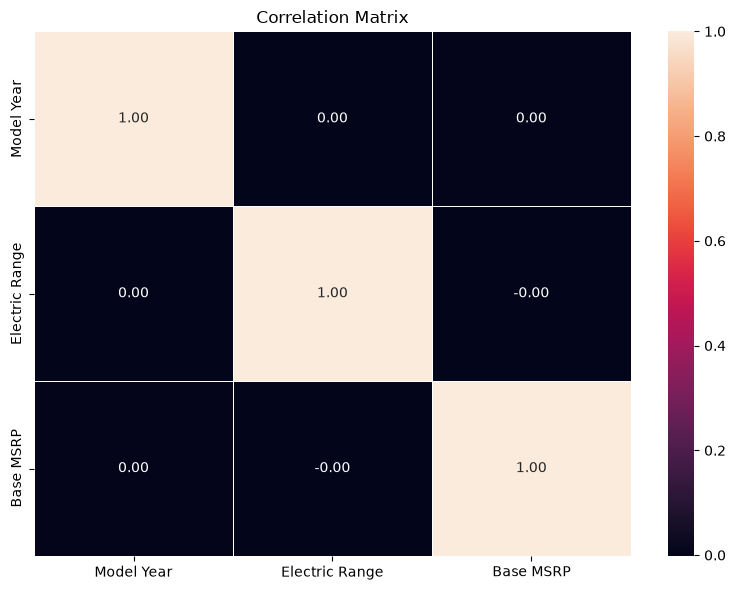

In [42]:
correlation = df[
    [
        "Model Year",
        "Electric Range",
        "Base MSRP"
    ]
].corr()

print("\n" + "=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

print(correlation.round(3))

correlation.to_csv(
    os.path.join(TABLE_DIR, "14_correlation_matrix.csv")
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "11_correlation_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 32. ELECTRIC UTILITY ANALYSIS
# ============================================================


In [45]:
utility_analysis = (
    df.groupby("Electric Utility")
    .agg(
        EV_Count=("DOL Vehicle ID", "count"),
        Average_Range=("Electric Range", "mean"),
        Average_Price=("Base MSRP", "mean")
    )
    .sort_values(
        "EV_Count",
        ascending=False
    )
    .reset_index()
)

utility_analysis["Market_Share_%"] = (
    utility_analysis["EV_Count"]
    / total_vehicles * 100
).round(2)

print("\n" + "=" * 70)
print("ELECTRIC UTILITY ANALYSIS")
print("=" * 70)

print(
    utility_analysis
    .round(2)
    .to_string(index=False)
)

utility_analysis.to_csv(
    os.path.join(TABLE_DIR, "15_utility_analysis.csv"),
    index=False
)



ELECTRIC UTILITY ANALYSIS
 Electric Utility  EV_Count  Average_Range  Average_Price  Market_Share_%
             TNEB      4335         295.92     2693801.80           16.98
            TPDDL      4321         299.76     2681155.51           16.92
            GUVNL      4281         298.03     2705986.07           16.77
           BESCOM      4215         298.72     2753545.07           16.51
            UPPCL      4213         298.68     2697213.02           16.50
Adani Electricity      4168         298.75     2696185.78           16.32


# ============================================================
# 33. STATE × EV TYPE ANALYSIS
# ============================================================


In [46]:
state_ev_type = pd.crosstab(
    df["State"],
    df["Electric Vehicle Type"]
)

print("\n" + "=" * 70)
print("STATE × EV TYPE")
print("=" * 70)

print(state_ev_type)

state_ev_type.to_csv(
    os.path.join(TABLE_DIR, "16_state_ev_type.csv")
)



STATE × EV TYPE
Electric Vehicle Type  Battery Electric Vehicle (BEV)  \
State                                                   
Andhra Pradesh                                   1238   
Bihar                                            1229   
Delhi                                             587   
Gujarat                                          1857   
Haryana                                          1213   
Karnataka                                        1851   
Kerala                                           1186   
Maharashtra                                      1876   
Odisha                                           1238   
Punjab                                           1212   
Rajasthan                                        1870   
Tamil Nadu                                       1973   
Telangana                                        1259   
Uttar Pradesh                                    1868   
West Bengal                                      1227   

Electric Vehi

# ============================================================
# 34. MANUFACTURER × EV TYPE
# ============================================================


In [47]:
manufacturer_ev_type = pd.crosstab(
    df["Make"],
    df["Electric Vehicle Type"]
)

print("\n" + "=" * 70)
print("MANUFACTURER × EV TYPE")
print("=" * 70)

print(manufacturer_ev_type)

manufacturer_ev_type.to_csv(
    os.path.join(TABLE_DIR, "17_manufacturer_ev_type.csv")
)



MANUFACTURER × EV TYPE
Electric Vehicle Type  Battery Electric Vehicle (BEV)  \
Make                                                    
Ather Energy                                     2716   
BYD India                                        2773   
Hyundai EV                                       2661   
MG Motor India                                   2643   
Mahindra Electric                                2725   
Ola Electric                                     2650   
TVS Motor                                        2776   
Tata Motors                                      2740   

Electric Vehicle Type  Plug-in Hybrid Electric Vehicle (PHEV)  
Make                                                           
Ather Energy                                              481  
BYD India                                                 473  
Hyundai EV                                                439  
MG Motor India                                            512  
Mahindra Electric    

# ============================================================
# 35. MANUFACTURER × CAFV
# ============================================================


In [48]:
manufacturer_cafv = pd.crosstab(
    df["Make"],
    df["Clean Alternative Fuel Vehicle (CAFV) Eligibility"]
)

manufacturer_cafv["Total"] = manufacturer_cafv.sum(axis=1)

if "Eligible" in manufacturer_cafv.columns:
    manufacturer_cafv["Eligibility_Rate_%"] = (
        manufacturer_cafv["Eligible"]
        / manufacturer_cafv["Total"]
        * 100
    ).round(2)

manufacturer_cafv = (
    manufacturer_cafv
    .sort_values(
        "Eligibility_Rate_%",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("MANUFACTURER CAFV ELIGIBILITY")
print("=" * 70)

print(manufacturer_cafv)

manufacturer_cafv.to_csv(
    os.path.join(TABLE_DIR, "18_manufacturer_cafv.csv")
)



MANUFACTURER CAFV ELIGIBILITY
Clean Alternative Fuel Vehicle (CAFV) Eligibility  Eligible  Not Eligible  \
Make                                                                        
Ola Electric                                           2541           599   
MG Motor India                                         2540           615   
TVS Motor                                              2601           635   
Tata Motors                                            2585           665   
Ather Energy                                           2538           659   
Mahindra Electric                                      2534           675   
Hyundai EV                                             2446           654   
BYD India                                              2561           685   

Clean Alternative Fuel Vehicle (CAFV) Eligibility  Total  Eligibility_Rate_%  
Make                                                                          
Ola Electric                            

# ============================================================
# 36. STATE RANGE ANALYSIS
# ============================================================

In [49]:
state_range = (
    df.groupby("State")
    .agg(
        Average_Range=("Electric Range", "mean"),
        Maximum_Range=("Electric Range", "max"),
        EV_Count=("DOL Vehicle ID", "count")
    )
    .sort_values(
        "Average_Range",
        ascending=False
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("STATES BY AVERAGE ELECTRIC RANGE")
print("=" * 70)

print(
    state_range
    .round(2)
    .to_string(index=False)
)

state_range.to_csv(
    os.path.join(TABLE_DIR, "19_state_range_analysis.csv"),
    index=False
)



STATES BY AVERAGE ELECTRIC RANGE
         State  Average_Range  Maximum_Range  EV_Count
         Delhi         308.51            518       700
     Karnataka         306.84            519      2172
        Punjab         303.37            519      1402
        Kerala         303.19            517      1389
 Uttar Pradesh         300.27            519      2187
     Rajasthan         298.35            519      2195
     Telangana         297.68            519      1495
Andhra Pradesh         296.71            519      1443
   Maharashtra         296.45            519      2262
       Gujarat         296.40            519      2177
        Odisha         296.20            519      1474
   West Bengal         295.75            519      1456
    Tamil Nadu         294.03            519      2287
       Haryana         292.86            519      1431
         Bihar         292.81            519      1463


# ============================================================
# 37. TOP CITIES
# ============================================================


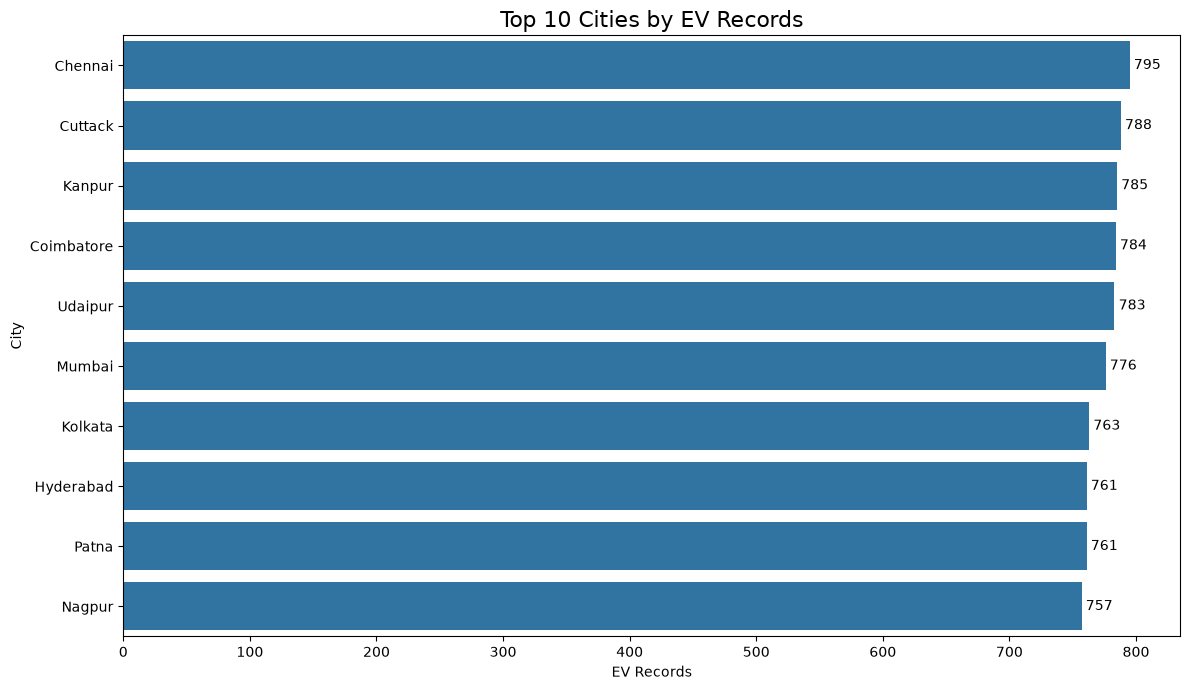

In [50]:
top_cities = (
    df["City"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_cities.columns = [
    "City",
    "EV_Count"
]

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_cities,
    y="City",
    x="EV_Count"
)

plt.title("Top 10 Cities by EV Records", fontsize=16)
plt.xlabel("EV Records")
plt.ylabel("City")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "12_top_cities.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 38. YEAR × EV TYPE
# ============================================================


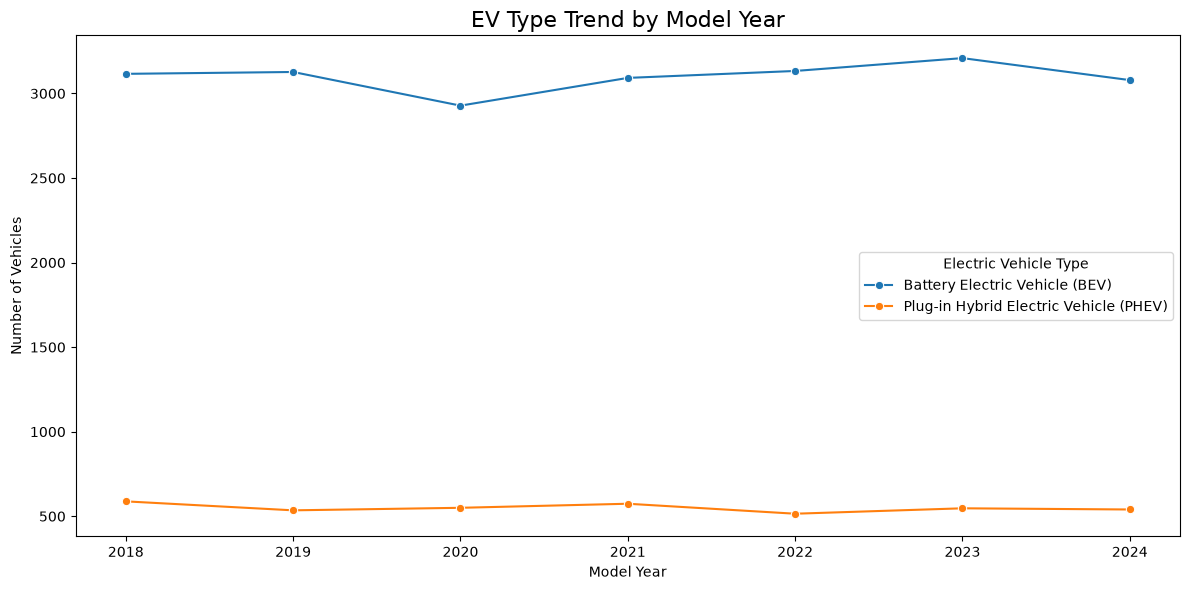

In [53]:
year_ev_type = (
    df.groupby(
        ["Model Year", "Electric Vehicle Type"]
    )
    .size()
    .reset_index(name="Vehicle_Count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=year_ev_type,
    x="Model Year",
    y="Vehicle_Count",
    hue="Electric Vehicle Type",
    marker="o"
)

plt.title("EV Type Trend by Model Year", fontsize=16)
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "13_ev_type_trend.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 39. YEAR × MANUFACTURER
# ============================================================


In [54]:
year_make = pd.crosstab(
    df["Model Year"],
    df["Make"]
)

print("\n" + "=" * 70)
print("MODEL YEAR × MANUFACTURER")
print("=" * 70)

print(year_make)

year_make.to_csv(
    os.path.join(TABLE_DIR, "20_year_manufacturer.csv")
)



MODEL YEAR × MANUFACTURER
Make        Ather Energy  BYD India  Hyundai EV  MG Motor India  \
Model Year                                                        
2018                 471        476         475             470   
2019                 457        479         419             453   
2020                 428        465         434             426   
2021                 452        477         449             443   
2022                 485        471         416             445   
2023                 458        472         457             465   
2024                 446        406         450             453   

Make        Mahindra Electric  Ola Electric  TVS Motor  Tata Motors  
Model Year                                                           
2018                      470           450        434          458  
2019                      435           472        497          450  
2020                      423           397        464          441  
2021               

# ============================================================
# 40. HIGH RANGE EVs
# ============================================================


In [55]:
high_range_threshold = df["Electric Range"].quantile(0.75)

high_range_evs = df[
    df["Electric Range"] >= high_range_threshold
].copy()

print("\n" + "=" * 70)
print("HIGH RANGE EV ANALYSIS")
print("=" * 70)

print(
    "High-range threshold:",
    round(high_range_threshold, 2)
)

print(
    "Number of high-range EV records:",
    len(high_range_evs)
)

print(
    "\nHigh-range vehicles by manufacturer:"
)

print(
    high_range_evs["Make"]
    .value_counts()
)



HIGH RANGE EV ANALYSIS
High-range threshold: 408.0
Number of high-range EV records: 6402

High-range vehicles by manufacturer:
Make
Mahindra Electric    853
BYD India            830
Ather Energy         827
Tata Motors          813
Ola Electric         798
TVS Motor            772
MG Motor India       766
Hyundai EV           743
Name: count, dtype: int64


# ============================================================
# 41. PREMIUM EV ANALYSIS
# ============================================================


In [56]:
premium_threshold = df["Base MSRP"].quantile(0.75)

premium_evs = df[
    df["Base MSRP"] >= premium_threshold
].copy()

print("\n" + "=" * 70)
print("PREMIUM EV ANALYSIS")
print("=" * 70)

print(
    "Premium price threshold:",
    f"₹{premium_threshold:,.0f}"
)

print(
    "Number of premium EV records:",
    len(premium_evs)
)

print(
    "\nPremium EVs by manufacturer:"
)

print(
    premium_evs["Make"]
    .value_counts()
)



PREMIUM EV ANALYSIS
Premium price threshold: ₹3,599,703
Number of premium EV records: 6384

Premium EVs by manufacturer:
Make
BYD India            821
TVS Motor            816
MG Motor India       814
Mahindra Electric    810
Ather Energy         809
Ola Electric         793
Tata Motors          771
Hyundai EV           750
Name: count, dtype: int64


# ============================================================
# 42. VALUE ANALYSIS
# ============================================================


In [57]:
# Range per ₹1 lakh of MSRP
df["Range_per_Lakh"] = (
    df["Electric Range"]
    / (df["Base MSRP"] / 100000)
)

value_analysis = (
    df.groupby(["Make", "Model"])
    .agg(
        Average_Range=("Electric Range", "mean"),
        Average_Price=("Base MSRP", "mean"),
        Range_per_Lakh=("Range_per_Lakh", "mean"),
        Vehicle_Count=("DOL Vehicle ID", "count")
    )
    .sort_values(
        "Range_per_Lakh",
        ascending=False
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("RANGE-TO-PRICE VALUE ANALYSIS")
print("=" * 70)

print(
    value_analysis
    .head(15)
    .round(2)
    .to_string(index=False)
)

value_analysis.to_csv(
    os.path.join(TABLE_DIR, "21_range_price_value.csv"),
    index=False
)



RANGE-TO-PRICE VALUE ANALYSIS
             Make    Model  Average_Range  Average_Price  Range_per_Lakh  Vehicle_Count
Mahindra Electric  Kona EV         306.11     2580033.14           14.57            399
        BYD India Nexon EV         302.17     2628660.99           14.28            408
   MG Motor India    iQube         306.94     2689053.61           14.24            402
Mahindra Electric Nexon EV         306.38     2653191.32           14.19            402
     Ather Energy  Kona EV         311.43     2673457.29           14.16            412
     Ather Energy   S1 Pro         301.95     2666354.70           14.10            405
   MG Motor India     450X         304.15     2656850.54           14.09            395
        TVS Motor  Kona EV         304.58     2658574.84           14.05            415
        BYD India   Atto 3         306.87     2739919.97           13.82            411
      Tata Motors    ZS EV         306.61     2684433.64           13.76            436
 

# ============================================================
# 43. TOP MODELS BY RANGE
# ============================================================


In [58]:
model_range = (
    df.groupby(["Make", "Model"])
    .agg(
        Average_Range=("Electric Range", "mean"),
        Vehicle_Count=("DOL Vehicle ID", "count")
    )
    .reset_index()
)

top_range = (
    model_range
    .sort_values("Average_Range", ascending=False)
    .head(10)
)

print("\n" + "=" * 70)
print("TOP 10 MODELS BY RANGE")
print("=" * 70)

print(
    top_range.round(2)
    .to_string(index=False)
)



TOP 10 MODELS BY RANGE
             Make    Model  Average_Range  Vehicle_Count
     Ather Energy  Kona EV         311.43            412
     Ather Energy    ZS EV         307.59            406
Mahindra Electric    ZS EV         307.29            427
       Hyundai EV   Atto 3         307.08            381
   MG Motor India    iQube         306.94            402
        BYD India   Atto 3         306.87            411
      Tata Motors    ZS EV         306.61            436
     Ola Electric Nexon EV         306.45            433
Mahindra Electric Nexon EV         306.38            402
      Tata Motors Nexon EV         306.12            408


# ============================================================
# 44. TOP MODELS BY PRICE
# ============================================================


In [59]:
model_price = (
    df.groupby(["Make", "Model"])
    .agg(
        Average_Price=("Base MSRP", "mean"),
        Average_Range=("Electric Range", "mean"),
        Vehicle_Count=("DOL Vehicle ID", "count")
    )
    .sort_values(
        "Average_Price",
        ascending=False
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("TOP 10 MODELS BY AVERAGE PRICE")
print("=" * 70)

print(
    model_price
    .head(10)
    .round(2)
    .to_string(index=False)
)

model_price.to_csv(
    os.path.join(TABLE_DIR, "22_model_price_analysis.csv"),
    index=False
)



TOP 10 MODELS BY AVERAGE PRICE
             Make    Model  Average_Price  Average_Range  Vehicle_Count
     Ather Energy    ZS EV     2806989.36         307.59            406
      Tata Motors     450X     2804860.01         304.48            408
     Ather Energy   XUV400     2798408.59         291.45            379
     Ather Energy     450X     2776330.80         302.26            400
Mahindra Electric     450X     2775314.36         288.01            407
      Tata Motors Nexon EV     2766088.14         306.12            408
       Hyundai EV Nexon EV     2761095.31         289.04            374
       Hyundai EV  Kona EV     2758576.04         299.63            408
   MG Motor India Nexon EV     2757225.68         296.21            403
        TVS Motor   Atto 3     2756463.71         291.23            416


# ============================================================
# 45. OUTLIER ANALYSIS
# ============================================================



OUTLIER ANALYSIS

Electric Range outliers: 0
Base MSRP outliers: 0


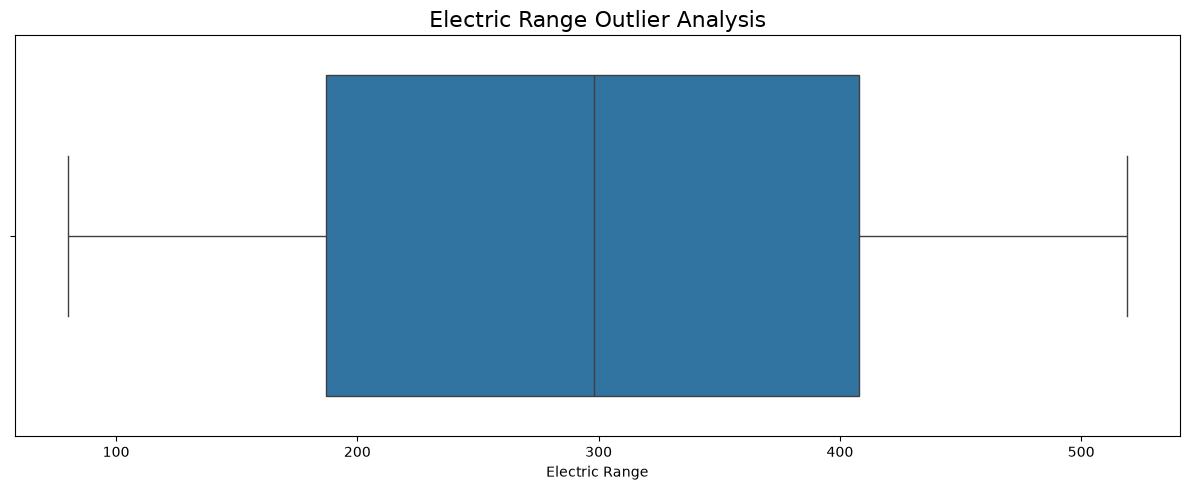

In [60]:
def find_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return outliers, lower, upper


range_outliers, range_lower, range_upper = find_outliers(
    df,
    "Electric Range"
)

price_outliers, price_lower, price_upper = find_outliers(
    df,
    "Base MSRP"
)

print("\n" + "=" * 70)
print("OUTLIER ANALYSIS")
print("=" * 70)

print(
    f"\nElectric Range outliers: {len(range_outliers)}"
)

print(
    f"Base MSRP outliers: {len(price_outliers)}"
)

# ============================================================
# 46. BOX PLOT — RANGE
# ============================================================

plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df["Electric Range"]
)

plt.title("Electric Range Outlier Analysis", fontsize=16)
plt.xlabel("Electric Range")

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "14_range_boxplot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 47. BOX PLOT — PRICE
# ============================================================


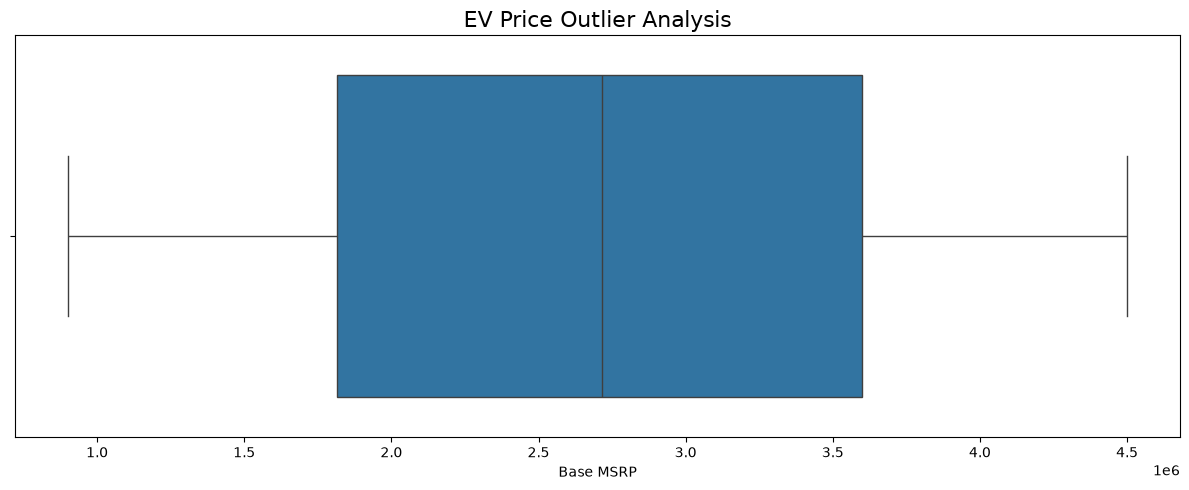

In [61]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df["Base MSRP"]
)

plt.title("EV Price Outlier Analysis", fontsize=16)
plt.xlabel("Base MSRP")

plt.tight_layout()

plt.savefig(
    os.path.join(CHART_DIR, "15_price_boxplot.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# ============================================================
# 48. AUTOMATED INSIGHT GENERATION
# ============================================================


In [62]:
print("\n" + "=" * 70)
print("AUTOMATED KEY INSIGHTS")
print("=" * 70)

# Largest state
largest_state = (
    state_analysis.iloc[0]["State"]
)

largest_state_count = (
    state_analysis.iloc[0]["EV_Count"]
)

# Largest manufacturer
largest_make = (
    manufacturer_analysis.iloc[0]["Make"]
)

largest_make_count = (
    manufacturer_analysis.iloc[0]["EV_Count"]
)

# Largest model
largest_model = (
    model_analysis.iloc[0]["Model"]
)

largest_model_count = (
    model_analysis.iloc[0]["EV_Count"]
)

# Highest range model
highest_range_model = (
    top_range_models.iloc[0]["Model"]
)

highest_range_value = (
    top_range_models.iloc[0]["Average_Range"]
)

# Highest range manufacturer
highest_range_make = (
    range_analysis.iloc[0]["Make"]
)

highest_range_make_value = (
    range_analysis.iloc[0]["Average_Range"]
)

# Most common EV type
most_common_ev_type = (
    ev_type_analysis.iloc[0]["EV_Type"]
)

most_common_ev_type_count = (
    ev_type_analysis.iloc[0]["Vehicle_Count"]
)

# Most common city
largest_city = (
    top_cities.iloc[0]["City"]
)

largest_city_count = (
    top_cities.iloc[0]["EV_Count"]
)

# Highest price manufacturer
highest_price_make = (
    price_analysis.iloc[0]["Make"]
)

highest_price_value = (
    price_analysis.iloc[0]["Average_Price"]
)

# Strongest range-price correlation
range_price_corr = (
    df["Electric Range"]
    .corr(df["Base MSRP"])
)



AUTOMATED KEY INSIGHTS


# ============================================================
# 49. PRINT INSIGHTS
# ============================================================


In [63]:
insights = []

insights.append(
    f"1. {largest_state} has the highest number of EV records "
    f"with {largest_state_count:,} vehicles."
)

insights.append(
    f"2. {largest_make} has the largest number of EV records "
    f"with {largest_make_count:,} vehicles."
)

insights.append(
    f"3. {largest_model} is the most frequently recorded EV model "
    f"with {largest_model_count:,} records."
)

insights.append(
    f"4. {most_common_ev_type} is the dominant EV type "
    f"with {most_common_ev_type_count:,} records."
)

insights.append(
    f"5. {highest_range_model} has the highest average electric range "
    f"at approximately {highest_range_value:.1f} km."
)

insights.append(
    f"6. {highest_range_make} has the highest average manufacturer-level "
    f"electric range at approximately {highest_range_make_value:.1f} km."
)

insights.append(
    f"7. {largest_city} is the city with the largest number of EV records "
    f"with {largest_city_count:,} vehicles."
)

insights.append(
    f"8. {highest_price_make} has the highest average Base MSRP "
    f"at approximately ₹{highest_price_value:,.0f}."
)

insights.append(
    f"9. The correlation between Electric Range and Base MSRP "
    f"is {range_price_corr:.2f}."
)

insights.append(
    f"10. The dataset contains {total_vehicles:,} EV records "
    f"covering {total_manufacturers} manufacturers, "
    f"{total_models} models, {total_states} states and "
    f"{total_cities} cities."
)

for insight in insights:
    print("\n" + insight)



1. Tamil Nadu has the highest number of EV records with 2,287 vehicles.

2. Tata Motors has the largest number of EV records with 3,250 vehicles.

3. ZS EV is the most frequently recorded EV model with 436 records.

4. Battery Electric Vehicle (BEV) is the dominant EV type with 21,684 records.

5. Kona EV has the highest average electric range at approximately 311.4 km.

6. Ather Energy has the highest average manufacturer-level electric range at approximately 300.6 km.

7. Chennai is the city with the largest number of EV records with 795 vehicles.

8. Ather Energy has the highest average Base MSRP at approximately ₹2,725,111.

9. The correlation between Electric Range and Base MSRP is -0.00.

10. The dataset contains 25,533 EV records covering 8 manufacturers, 8 models, 15 states and 35 cities.



# ============================================================
# 50. SAVE INSIGHTS
# ============================================================


In [64]:
with open(
    os.path.join(OUTPUT_DIR, "Key_Insights.txt"),
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "INDIA ELECTRIC VEHICLE MARKET ANALYSIS\n"
    )

    file.write("=" * 70 + "\n\n")

    for insight in insights:
        file.write(insight + "\n\n")


# ============================================================
# 51. MASTER ANALYTICS TABLE
# ============================================================


In [65]:
master_summary = pd.DataFrame({
    "Metric": [
        "Total EV Records",
        "Total Manufacturers",
        "Total Models",
        "Total States",
        "Total Cities",
        "Average Range",
        "Median Range",
        "Average MSRP",
        "Median MSRP",
        "BEV Count",
        "PHEV Count",
        "CAFV Eligible Count",
        "Range-Price Correlation"
    ],

    "Value": [
        total_vehicles,
        total_manufacturers,
        total_models,
        total_states,
        total_cities,
        round(average_range, 2),
        round(median_range, 2),
        round(average_price, 2),
        round(median_price, 2),
        bev_count,
        phev_count,
        eligible_count,
        round(range_price_corr, 3)
    ]
})

master_summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "MASTER_ANALYTICS_SUMMARY.csv"
    ),
    index=False
)


# ============================================================
# 52. SAVE CLEAN DATA
# ============================================================


In [66]:
df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "EV_Cleaned_Analysis_Data.csv"
    ),
    index=False
)



# ============================================================
# 53. FINAL MESSAGE
# ============================================================


In [68]:
print("\n" + "=" * 70)
print("PROJECT COMPLETED")
print("=" * 70)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nGenerated folders:")
print("1. Charts/")
print("2. Tables/")

print("\nGenerated files include:")
print("- Data profile")
print("- KPI summary")
print("- State analysis")
print("- City analysis")
print("- Manufacturer analysis")
print("- Model analysis")
print("- EV type analysis")
print("- CAFV analysis")
print("- Range analysis")
print("- Price analysis")
print("- Utility analysis")
print("- Correlation analysis")
print("- Range/price value analysis")
print("- Key insights")
print("- Cleaned analysis dataset")

print("\n" + "=" * 70)
print("END OF ANALYSIS")
print("=" * 70)


PROJECT COMPLETED

Output directory:
EV_Analysis_Output

Generated folders:
1. Charts/
2. Tables/

Generated files include:
- Data profile
- KPI summary
- State analysis
- City analysis
- Manufacturer analysis
- Model analysis
- EV type analysis
- CAFV analysis
- Range analysis
- Price analysis
- Utility analysis
- Correlation analysis
- Range/price value analysis
- Key insights
- Cleaned analysis dataset

END OF ANALYSIS
